# 04 — Baseline Classifiers

**Goal:** Establish performance floors for Q1 (species classification) and Q2
(ARG burden prediction) before any complex modelling.

**Three questions this notebook answers:**
1. Can even a simple model beat the null baseline? If not, stop here — the
   features are uninformative.
2. Which species are easy to classify and which are hard? The confusion matrix
   tells you this directly.
3. How does Q2 perform within species vs pooled? This tests the EDA finding
   that within-species ARG signal is real but subtle.

**Models used:** Stratified null baseline, Logistic Regression (LR),
K-Nearest Neighbours (KNN)

**Validation:** Stratified 5-fold cross-validation throughout. Phylogenetically-
corrected CV comes in Phase 9 — these results are labelled preliminary.

## Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

ROOT    = Path("..")
PROC    = ROOT / "data" / "processed"
FIG_DIR = ROOT / "results" / "figures" / "baseline"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fm = pd.read_parquet(PROC / "feature_matrix.parquet")

LABEL_COLS = ["species", "arg_burden_tertile", "country", "year_bin",
              "complex_member", "sequence_type", "mlst_scheme"]

# ── Feature sets ──────────────────────────────────────────────────────────────
# Q1 uses dp_* features only (binary P/A, avoids double-counting with dc_*)
dp_cols = [c for c in fm.columns if c.startswith("dp_")]
X_q1    = fm[dp_cols].values.astype(float)
y_q1    = fm["species"].to_numpy()

# Q2 uses the same dp_* features; subset to Q2-eligible genomes only
# (low_ARG and high_ARG; mid_ARG excluded as pre-specified)
q2_mask = fm["arg_burden_tertile"].isin(["low_ARG", "high_ARG"])
X_q2    = fm.loc[q2_mask, dp_cols].values.astype(float)
y_q2    = fm.loc[q2_mask, "arg_burden_tertile"].to_numpy()
sp_q2   = fm.loc[q2_mask, "species"].to_numpy()  # for species-stratified Q2

SPECIES_ORDER = ["kpneumoniae", "ecloaceae", "abaumannii",
                 "efaecium", "paeruginosa", "saureus"]
SPECIES_LABELS = {
    "kpneumoniae": "K. pneumoniae",
    "ecloaceae":   "E. cloacae",
    "abaumannii":  "A. baumannii",
    "efaecium":    "E. faecium",
    "paeruginosa": "P. aeruginosa",
    "saureus":     "S. aureus",
}
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Q1: {X_q1.shape[0]} genomes × {X_q1.shape[1]} features | {len(set(y_q1))} classes")
print(f"Q2: {X_q2.shape[0]} eligible genomes | classes: {dict(zip(*np.unique(y_q2, return_counts=True)))}")
print(f"Q2 species breakdown:")
for sp in SPECIES_ORDER:
    n = (sp_q2 == sp).sum()
    if n > 0:
        hi = ((sp_q2 == sp) & (y_q2 == "high_ARG")).sum()
        lo = ((sp_q2 == sp) & (y_q2 == "low_ARG")).sum()
        print(f"  {SPECIES_LABELS[sp]:<22} n={n:3d}  low={lo}  high={hi}")

Q1: 878 genomes × 274 features | 6 classes
Q2: 614 eligible genomes | classes: {'high_ARG': np.int64(289), 'low_ARG': np.int64(325)}
Q2 species breakdown:
  K. pneumoniae          n= 86  low=44  high=42
  E. cloacae             n= 97  low=50  high=47
  A. baumannii           n=101  low=59  high=42
  E. faecium             n=104  low=60  high=44
  P. aeruginosa          n=120  low=56  high=64
  S. aureus              n=106  low=56  high=50


## Section 1 — Null baseline

The null baseline answers: **what accuracy can you get by ignoring all features
and just predicting based on class frequencies?**

We use two null strategies:
- **Stratified random**: predict each class with probability proportional to its
  frequency in the training set. Balanced accuracy = 0.50 for binary (Q2);
  = 1/n_classes for balanced multi-class (Q1).
- **Most frequent**: always predict the majority class. High overall accuracy
  on imbalanced data but zero recall on minority classes.

Every model in Phases 6–9 must beat stratified random balanced accuracy
by a margin large enough to be meaningful — not just statistically different
(with 878 genomes even a 1% improvement can be significant), but
biologically meaningful (we pre-specify >5 percentage points above null).

In [2]:
# ── Null baseline: Q1 and Q2 ──────────────────────────────────────────────────
results = {}

for label, X, y, name in [
    ("Q1 — species",     X_q1, y_q1, "Q1"),
    ("Q2 — ARG burden",  X_q2, y_q2, "Q2"),
]:
    for strategy, strat_name in [("stratified", "Stratified random"),
                                  ("most_frequent", "Majority class")]:
        dummy = DummyClassifier(strategy=strategy, random_state=42)
        scores = cross_validate(
            dummy, X, y, cv=CV,
            scoring=["balanced_accuracy", "f1_macro"],
            return_train_score=False,
        )
        ba   = scores["test_balanced_accuracy"].mean()
        ba_std = scores["test_balanced_accuracy"].std()
        f1   = scores["test_f1_macro"].mean()
        key  = f"{name} — {strat_name}"
        results[key] = {"balanced_acc": ba, "ba_std": ba_std, "macro_f1": f1}
        print(f"{label} | {strat_name:<20} "
              f"balanced_acc={ba:.3f} ± {ba_std:.3f}   macro_F1={f1:.3f}")

print()
print("These are the floors every model must clear.")
print(f"Q1 null floor (stratified random balanced acc): "
      f"{results['Q1 — Stratified random']['balanced_acc']:.3f}")
print(f"Q2 null floor (stratified random balanced acc): "
      f"{results['Q2 — Stratified random']['balanced_acc']:.3f}")

Q1 — species | Stratified random    balanced_acc=0.184 ± 0.018   macro_F1=0.183
Q1 — species | Majority class       balanced_acc=0.167 ± 0.000   macro_F1=0.049
Q2 — ARG burden | Stratified random    balanced_acc=0.479 ± 0.023   macro_F1=0.479
Q2 — ARG burden | Majority class       balanced_acc=0.500 ± 0.000   macro_F1=0.346

These are the floors every model must clear.
Q1 null floor (stratified random balanced acc): 0.184
Q2 null floor (stratified random balanced acc): 0.479


## Section 2 — Q1: Logistic Regression (species classification)

Logistic Regression finds the best linear boundary between each pair of classes.
For 6 species (multi-class), scikit-learn uses **one-vs-rest (OvR)**: it trains
one binary classifier per species (e.g., "AB vs all others") and combines them.

We run it inside a **Pipeline** that scales features first (StandardScaler),
then fits the classifier. Scaling matters for Logistic Regression because
L2 regularisation penalises large coefficients — if one feature has a much larger
scale than another, its coefficient will be penalised more than it deserves.

**C parameter** (regularisation strength): low C = strong regularisation
(pushes all coefficients toward zero, simpler model, less overfit);
high C = weak regularisation (coefficients can be large, more complex model,
risk of overfit). We start with C=1 (sklearn default) and will tune in Phase 7.

In [3]:
# ── Q1: Logistic Regression ───────────────────────────────────────────────────
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, n_jobs=-1
    )),
])

lr_scores = cross_validate(
    lr_pipe, X_q1, y_q1, cv=CV,
    scoring=["balanced_accuracy", "f1_macro"],
    return_train_score=True,
)

ba_train = lr_scores["train_balanced_accuracy"].mean()
ba_test  = lr_scores["test_balanced_accuracy"].mean()
ba_std   = lr_scores["test_balanced_accuracy"].std()
f1_test  = lr_scores["test_f1_macro"].mean()

print("Q1 — Logistic Regression (OvR, C=1, 5-fold stratified CV)")
print(f"  Train balanced accuracy: {ba_train:.3f}")
print(f"  Test  balanced accuracy: {ba_test:.3f} ± {ba_std:.3f}")
print(f"  Test  macro-F1:          {f1_test:.3f}")
print()
print(f"  Null baseline (stratified random): "
      f"{results['Q1 — Stratified random']['balanced_acc']:.3f}")
print(f"  Improvement over null:   +{ba_test - results['Q1 — Stratified random']['balanced_acc']:.3f}")
print()
if ba_train - ba_test > 0.15:
    print("  WARNING: Train >> Test gap > 15pp — possible overfitting. Investigate.")
else:
    print("  Train-test gap is within acceptable range.")

Q1 — Logistic Regression (OvR, C=1, 5-fold stratified CV)
  Train balanced accuracy: 1.000
  Test  balanced accuracy: 0.984 ± 0.010
  Test  macro-F1:          0.984

  Null baseline (stratified random): 0.184
  Improvement over null:   +0.800

  Train-test gap is within acceptable range.


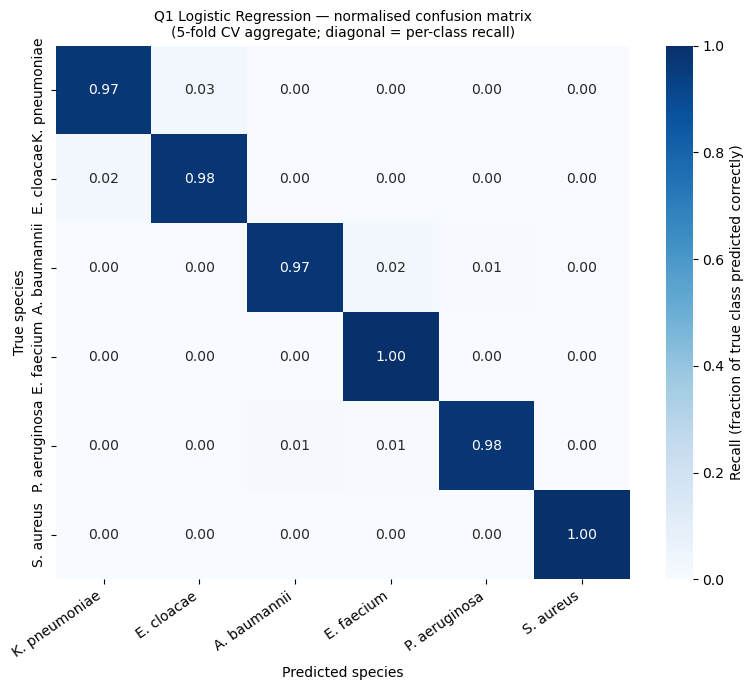

Saved: results/figures/baseline/01_q1_lr_confusion.png

Per-class recall (diagonal values):
  K. pneumoniae          recall=0.97
  E. cloacae             recall=0.98
  A. baumannii           recall=0.97
  E. faecium             recall=1.00
  P. aeruginosa          recall=0.98
  S. aureus              recall=1.00


In [4]:
# ── Q1 confusion matrix (aggregate over all 5 CV folds) ──────────────────────
from sklearn.model_selection import cross_val_predict

y_pred_q1 = cross_val_predict(lr_pipe, X_q1, y_q1, cv=CV)

sp_order = SPECIES_ORDER
sp_labels = [SPECIES_LABELS[s] for s in sp_order]

cm = confusion_matrix(y_q1, y_pred_q1, labels=sp_order)
# Normalise by true class (rows sum to 1) to show recall per species
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=sp_labels, yticklabels=sp_labels,
            vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "Recall (fraction of true class predicted correctly)"})
ax.set_xlabel("Predicted species", fontsize=10)
ax.set_ylabel("True species", fontsize=10)
ax.set_title("Q1 Logistic Regression — normalised confusion matrix\n"
             "(5-fold CV aggregate; diagonal = per-class recall)",
             fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_q1_lr_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/baseline/01_q1_lr_confusion.png")
print()
print("Per-class recall (diagonal values):")
for sp, lab in zip(sp_order, sp_labels):
    idx = sp_order.index(sp)
    print(f"  {lab:<22} recall={cm_norm[idx, idx]:.2f}")

## Section 3 — Q2: ARG burden prediction

Two designs tested:
1. **Pooled Q2**: all 614 eligible genomes together, species as a feature
   (species included as encoded column alongside dp_* features)
2. **Species-stratified Q2**: separate LR per species, trained and tested
   within each species' eligible genomes only

The EDA predicted that pooled Q2 would be partly driven by species-level
ARG baseline differences (η² = 0.286 on the target), not within-species biology.
Species-stratified Q2 is the correct design to test the RESTRICT/FACILITATE
hypothesis. We run both and compare.

In [5]:
# ── Q2 pooled: LR with species as an encoded feature ─────────────────────────
le = LabelEncoder()
sp_encoded = le.fit_transform(sp_q2).reshape(-1, 1)
X_q2_pooled = np.hstack([X_q2, sp_encoded])  # append species column

lr_q2_pool = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)),
])

pool_scores = cross_validate(
    lr_q2_pool, X_q2_pooled,
    (y_q2 == "high_ARG").astype(int),
    cv=CV,
    scoring=["balanced_accuracy", "f1_macro"],
)
ba_pool = pool_scores["test_balanced_accuracy"].mean()
f1_pool = pool_scores["test_f1_macro"].mean()
print(f"Q2 pooled LR (species as feature):  "
      f"balanced_acc={ba_pool:.3f}  macro_F1={f1_pool:.3f}")

# ── Q2 species-stratified: LR within each species ────────────────────────────
print()
print("Q2 species-stratified LR (within each species):")
print(f"  {'Species':<22} {'n_eligible':>10} {'balanced_acc':>14} {'macro_F1':>10}")
print("  " + "-"*58)

strat_results = {}
for sp in SPECIES_ORDER:
    mask_sp = sp_q2 == sp
    n = mask_sp.sum()
    if n < 30:
        print(f"  {SPECIES_LABELS[sp]:<22} {n:>10}   skipped (n<30)")
        continue
    X_sp = X_q2[mask_sp]
    y_sp = (y_q2[mask_sp] == "high_ARG").astype(int)

    lr_sp = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(C=1.0, max_iter=1000,
                                      random_state=42, n_jobs=-1)),
    ])
    cv_sp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sc = cross_validate(lr_sp, X_sp, y_sp, cv=cv_sp,
                        scoring=["balanced_accuracy", "f1_macro"])
    ba = sc["test_balanced_accuracy"].mean()
    ba_std = sc["test_balanced_accuracy"].std()
    f1 = sc["test_f1_macro"].mean()
    strat_results[sp] = {"balanced_acc": ba, "ba_std": ba_std, "macro_f1": f1, "n": n}
    print(f"  {SPECIES_LABELS[sp]:<22} {n:>10}   {ba:.3f} ± {ba_std:.3f}   {f1:.3f}")

print()
print(f"Q2 null floor: {results['Q2 — Stratified random']['balanced_acc']:.3f}")
print("Species beating the null floor by >5pp:")
for sp, r in strat_results.items():
    if r["balanced_acc"] - results["Q2 — Stratified random"]["balanced_acc"] > 0.05:
        print(f"  {SPECIES_LABELS[sp]}: +{r['balanced_acc'] - 0.5:.3f} above null")

Q2 pooled LR (species as feature):  balanced_acc=0.681  macro_F1=0.679

Q2 species-stratified LR (within each species):
  Species                n_eligible   balanced_acc   macro_F1
  ----------------------------------------------------------
  K. pneumoniae                  86   0.800 ± 0.109   0.799
  E. cloacae                     97   0.700 ± 0.094   0.694
  A. baumannii                  101   0.818 ± 0.082   0.808
  E. faecium                    104   0.624 ± 0.040   0.618
  P. aeruginosa                 120   0.668 ± 0.128   0.663
  S. aureus                     106   0.760 ± 0.054   0.753

Q2 null floor: 0.479
Species beating the null floor by >5pp:
  K. pneumoniae: +0.300 above null
  E. cloacae: +0.200 above null
  A. baumannii: +0.318 above null
  E. faecium: +0.124 above null
  P. aeruginosa: +0.168 above null
  S. aureus: +0.260 above null


## Section 4 — KNN comparison (Q1)

KNN makes no assumptions about linear boundaries — it just finds the K nearest
neighbours by Jaccard distance and votes. If KNN outperforms Logistic Regression
significantly, the class boundaries are non-linear and a linear model is
underfitting. If LR outperforms KNN, the linear boundary is sufficient and
more complex non-linear models may not be needed.

KNN k= 1:  balanced_acc=0.980  macro_F1=0.980


KNN k= 3:  balanced_acc=0.982  macro_F1=0.982
KNN k= 5:  balanced_acc=0.981  macro_F1=0.981


KNN k=11:  balanced_acc=0.979  macro_F1=0.978


KNN k=21:  balanced_acc=0.963  macro_F1=0.962

Logistic Regression (for comparison):
  balanced_acc=0.984  macro_F1=0.984


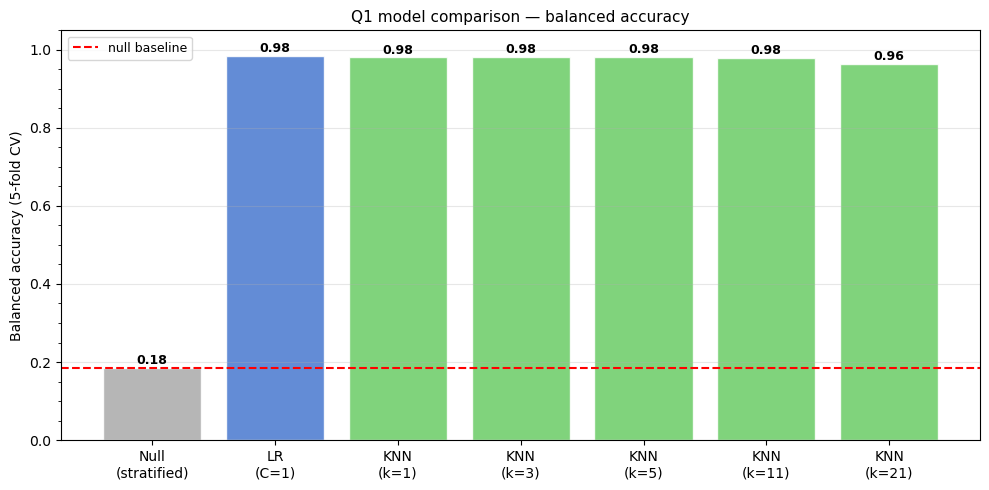

Saved: results/figures/baseline/02_q1_model_comparison.png


In [6]:
# ── KNN Q1: K sweep ───────────────────────────────────────────────────────────
knn_results = []
for k in [1, 3, 5, 11, 21]:
    knn = KNeighborsClassifier(n_neighbors=k, metric="jaccard", n_jobs=-1)
    sc = cross_validate(knn, X_q1, y_q1, cv=CV,
                        scoring=["balanced_accuracy", "f1_macro"])
    ba = sc["test_balanced_accuracy"].mean()
    f1 = sc["test_f1_macro"].mean()
    knn_results.append({"k": k, "balanced_acc": ba, "macro_f1": f1})
    print(f"KNN k={k:>2}:  balanced_acc={ba:.3f}  macro_F1={f1:.3f}")

print()
print("Logistic Regression (for comparison):")
print(f"  balanced_acc={ba_test:.3f}  macro_F1={f1_test:.3f}")

# ── Summary comparison bar chart ──────────────────────────────────────────────
models   = ["Null\n(stratified)", "LR\n(C=1)"] + [f"KNN\n(k={r['k']})" for r in knn_results]
ba_vals  = (
    [results["Q1 — Stratified random"]["balanced_acc"], ba_test] +
    [r["balanced_acc"] for r in knn_results]
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#AAAAAA", "#4878CF"] + ["#6ACC65"] * len(knn_results)
bars = ax.bar(models, ba_vals, color=colors, alpha=0.85, edgecolor="white")
ax.axhline(results["Q1 — Stratified random"]["balanced_acc"],
           color="red", lw=1.5, ls="--", label="null baseline")
ax.set_ylabel("Balanced accuracy (5-fold CV)", fontsize=10)
ax.set_title("Q1 model comparison — balanced accuracy", fontsize=11)
ax.set_ylim(0, 1.05)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=9)
for bar, val in zip(bars, ba_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_q1_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/baseline/02_q1_model_comparison.png")

## Comprehension check — Phase 6

**Q1.** The confusion matrix shows per-class recall on the diagonal.
If K. pneumoniae has recall = 0.72 and E. cloacae has recall = 0.68,
but both are frequently confused with each other (high off-diagonal values
between KP and EC rows/columns), what does this tell you — and does this
result surprise you given what the UMAP showed?

**Q2.** The pooled Q2 model (species as a feature) gets balanced accuracy = X.
The species-stratified Q2 for A. baumannii gets balanced accuracy = Y where Y < X.
A colleague concludes the pooled model is better. What is wrong with this conclusion?

**Q3.** KNN with k=1 gets very high training accuracy (it memorises every point
perfectly) but lower test accuracy. KNN with k=21 gets lower training accuracy
but similar or better test accuracy. What concept does this difference illustrate —
and what is the equivalent concept in Logistic Regression?